In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import joblib

In [2]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)

from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [3]:
df = pd.read_csv("data/Salary.csv")

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race,Senior
0,32.0,Male,1,Software Engineer,5.0,90000.0,UK,White,0
1,28.0,Female,2,Data Analyst,3.0,65000.0,USA,Hispanic,0
2,45.0,Male,3,Manager,15.0,150000.0,Canada,White,1
3,36.0,Female,1,Sales Associate,7.0,60000.0,USA,Hispanic,0
4,52.0,Male,2,Director,20.0,200000.0,USA,Asian,0


In [4]:
df.shape

(5144, 9)

In [5]:
df = df.drop_duplicates().reset_index(drop=True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop(columns=["Race"])

df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary', 'Country', 'Senior'],
      dtype='object')

In [8]:
df["Salary_Band"] = pd.qcut(
    df["Salary"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["Salary", "Salary_Band"]].head()

,Salary,Salary_Band
0,90000.0,Medium
1,65000.0,Low
2,150000.0,High
3,60000.0,Low
4,200000.0,High


In [9]:
df["Salary_Band"].value_counts()

Salary_Band
Low       1736
High      1707
Medium    1701
Name: count, dtype: int64

## Salary Band Distribution

Before training classification models, it is important to examine the distribution of the target variable.  
This plot shows how many records fall into each salary band (Low, Medium, High).  

Balanced classes help classifiers learn better and prevent bias toward one category.

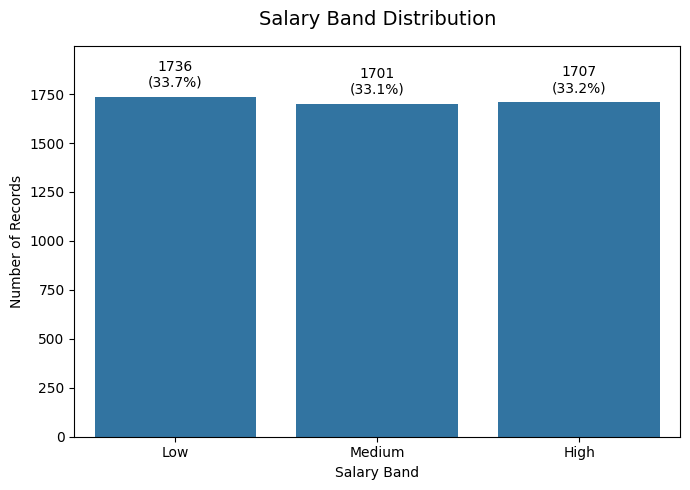

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Salary_Band",
    order=["Low", "Medium", "High"]
)

total = len(df)

# add headroom above bars
ax.set_ylim(0, max(df["Salary_Band"].value_counts()) * 1.15)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    
    ax.annotate(
        f"{count}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width()/2, count),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0,5),
        textcoords="offset points"
    )

plt.title("Salary Band Distribution", fontsize=14, pad=15)
plt.xlabel("Salary Band")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.show()

## Feature and Target Preparation

For the classification task, we predict the **salary band category** instead of the exact salary value.

The dataset features remain the same as the regression task, while the target variable becomes **Salary_Band**.

Features used for prediction:

- Age
- Gender
- Education Level
- Job Title
- Years of Experience
- Country
- Senior

The columns **Salary** and **Salary_Band** are removed from the feature set.

In [11]:
X = df.drop(columns=["Salary", "Salary_Band"])
y = df["Salary_Band"]

X.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Country,Senior
0,32.0,Male,1,Software Engineer,5.0,UK,0
1,28.0,Female,2,Data Analyst,3.0,USA,0
2,45.0,Male,3,Manager,15.0,Canada,1
3,36.0,Female,1,Sales Associate,7.0,USA,0
4,52.0,Male,2,Director,20.0,USA,0


## Train-Test Split

The dataset is divided into training and testing sets.

- **80% Training Data**
- **20% Testing Data**

Stratified sampling is used to ensure that the distribution of salary bands (Low, Medium, High) remains balanced in both sets.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (4115, 7)
Testing shape: (1029, 7)


## Data Preprocessing Pipeline

Machine learning models cannot directly process categorical variables such as job titles or country names.

Therefore a preprocessing pipeline is created to transform the data before model training.

The preprocessing steps include:

Numerical features:
- Age
- Education Level
- Years of Experience
- Senior

These are standardized using **StandardScaler**.

Categorical features:
- Gender
- Job Title
- Country

These are converted into numerical format using **OneHotEncoder**.

The preprocessing pipeline ensures that all transformations applied during training are also applied during prediction.

## Preprocessing Pipelines

Two preprocessing pipelines are defined:

1. **Scaled Preprocessor**  
   Used for models that depend on feature magnitude (Logistic Regression, SVM, KNN, Neural Networks).

2. **Unscaled Preprocessor**  
   Used for tree-based ensemble models where scaling is unnecessary (Decision Trees, Random Forest, Bagging, Gradient Boosting, etc.).

In [13]:
numeric_features = [
    "Age",
    "Education Level",
    "Years of Experience",
    "Senior"
]

categorical_features = [
    "Gender",
    "Job Title",
    "Country"
]

# ---------- UNSCALED PIPELINE (keeps original variable name) ----------

numeric_transformer = "passthrough"

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ---------- SCALED PIPELINE ----------

numeric_transformer_scaled = StandardScaler()

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Classification Models

In order to determine the most suitable algorithm for salary band prediction, multiple classification models are trained and evaluated.

The following algorithms are considered:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Gradient Boosting Classifier
5. AdaBoost Classifier
6. Support Vector Machine (SVM)

Each model is trained using the same preprocessing pipeline to ensure fair comparison.

In [14]:
models = {

    # Linear Models
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "scaled": True
    },

    "Ridge Classifier": {
        "model": RidgeClassifier(),
        "scaled": True
    },

    # Tree Models
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "scaled": False
    },

    # Bagging Ensembles
    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),
        "scaled": False
    },

    "Extra Trees": {
        "model": ExtraTreesClassifier(
            n_estimators=200,
            random_state=42
        ),
        "scaled": False
    },

    "Bagging": {
        "model": BaggingClassifier(
            n_estimators=100,
            random_state=42
        ),
        "scaled": False
    },

    # Boosting Ensembles
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "scaled": False
    },

    "Hist Gradient Boosting": {
        "model": HistGradientBoostingClassifier(random_state=42),
        "scaled": False
    },

    "AdaBoost": {
        "model": AdaBoostClassifier(random_state=42),
        "scaled": False
    },

    # Support Vector Machines
    "SVM (RBF)": {
        "model": SVC(kernel="rbf"),
        "scaled": True
    },

    "Linear SVM": {
        "model": LinearSVC(),
        "scaled": True
    },

    # Distance Based
    "KNN": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "scaled": True
    },

    # Probabilistic Models
    "Gaussian NB": {
        "model": GaussianNB(),
        "scaled": False
    },

    "Bernoulli NB": {
        "model": BernoulliNB(),
        "scaled": False
    },

    "Quadratic Discriminant Analysis": {
        "model": QuadraticDiscriminantAnalysis(),
        "scaled": True
    },

    # Neural Network
    "MLP Neural Network": {
        "model": MLPClassifier(
            hidden_layer_sizes=(100,),
            max_iter=500,
            random_state=42
        ),
        "scaled": True
    }
}

## Model Training and Evaluation

Each classification model is trained using the training dataset and evaluated on the test dataset.

The following evaluation metrics are calculated:

- Accuracy
- Precision
- Recall
- F1 Score

The F1 Score is used as the primary metric for selecting the best-performing model since it balances precision and recall.

In [15]:
import time

results = []

for name, entry in models.items():

    model = entry["model"]

    # Choose correct preprocessing pipeline
    if entry["scaled"]:
        chosen_preprocessor = preprocessor_scaled
    else:
        chosen_preprocessor = preprocessor

    try:
        start_time = time.time()

        pipeline = Pipeline(
            steps=[
                ("preprocessor", chosen_preprocessor),
                ("classifier", model)
            ]
        )

        pipeline.fit(X_train, y_train)

        train_time = time.time() - start_time

        # Predictions
        y_pred_train = pipeline.predict(X_train)
        y_pred_test = pipeline.predict(X_test)

        # Accuracy
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)

        # Precision / Recall / F1
        prec = precision_score(y_test, y_pred_test, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred_test, average="macro", zero_division=0)

        f1_test = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
        f1_train = f1_score(y_train, y_pred_train, average="macro", zero_division=0)

        results.append({
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Accuracy": test_acc,
            "Train F1": f1_train,
            "Test F1": f1_test,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1_test,
            "Accuracy Gap": train_acc - test_acc,
            "F1 Gap": f1_train - f1_test,
            "Training Time (s)": train_time
        })

    except Exception as e:
        results.append({
            "Model": name,
            "Error": str(e)
        })

In [16]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="F1 Score", ascending=False)

,Model,Train Accuracy,Test Accuracy,Accuracy,Train F1,Test F1,Precision,Recall,F1 Score,Accuracy Gap,F1 Gap,Training Time (s),Error
7,Hist Gradient Boosting,0.989793,0.965986,0.965986,0.989776,0.965795,0.965955,0.965887,0.965795,0.023807,0.023981,3.996600,NaN
3,Random Forest,0.990765,0.958212,0.958212,0.990753,0.958005,0.958104,0.958129,0.958005,0.032554,0.032748,0.976549,NaN
5,Bagging,0.990765,0.957240,0.957240,0.990754,0.956986,0.957249,0.957129,0.956986,0.033525,0.033768,1.476548,NaN
2,Decision Tree,0.990765,0.948494,0.948494,0.990748,0.948118,0.948465,0.948308,0.948118,0.042272,0.042630,0.034937,NaN
4,Extra Trees,0.990765,0.943635,0.943635,0.990748,0.943232,0.943465,0.943494,0.943232,0.047131,0.047516,1.365447,NaN
15,MLP Neural Network,0.971567,0.937804,0.937804,0.971374,0.936962,0.938299,0.937499,0.936962,0.033764,0.034412,8.829574,NaN
6,Gradient Boosting,0.925638,0.935860,0.935860,0.925155,0.935216,0.935697,0.935558,0.935216,-0.010222,-0.010062,3.079650,NaN
9,SVM (RBF),0.898906,0.899903,0.899903,0.898071,0.898468,0.899797,0.899448,0.898468,-0.000996,-0.000398,0.718172,NaN
0,Logistic Regression,0.878736,0.888241,0.888241,0.878347,0.887355,0.887198,0.887834,0.887355,-0.009505,-0.009008,0.168454,NaN
11,KNN,0.904253,0.881438,0.881438,0.904073,0.880880,0.881684,0.881264,0.880880,0.022814,0.023193,0.013574,NaN


In [17]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Encode target labels for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train/test split for encoded target
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# XGBoost pipeline
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42
        ))
    ]
)

# Train
xgb_pipeline.fit(X_train_xgb, y_train_xgb)

# Predictions
y_train_pred = xgb_pipeline.predict(X_train_xgb)
y_test_pred = xgb_pipeline.predict(X_test_xgb)

# Metrics
train_acc = accuracy_score(y_train_xgb, y_train_pred)
test_acc = accuracy_score(y_test_xgb, y_test_pred)

f1_train = f1_score(y_train_xgb, y_train_pred, average="macro")
f1_test = f1_score(y_test_xgb, y_test_pred, average="macro")

print("XGBoost Train Accuracy:", train_acc)
print("XGBoost Test Accuracy:", test_acc)

print("XGBoost Train F1:", f1_train)
print("XGBoost Test F1:", f1_test)

print("Accuracy Gap:", train_acc - test_acc)
print("F1 Gap:", f1_train - f1_test)

XGBoost Train Accuracy: 0.9808019441069259
XGBoost Test Accuracy: 0.9630709426627794
XGBoost Train F1: 0.9807491528328692
XGBoost Test F1: 0.9628455767401327
Accuracy Gap: 0.01773100144414652
F1 Gap: 0.017903576092736517


In [18]:
xgb_result = {
    "Model": "XGBoost",
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc,
    "Accuracy": test_acc,
    "Train F1": f1_train,
    "Test F1": f1_test,
    "Precision": precision_score(y_test_xgb, y_test_pred, average="macro"),
    "Recall": recall_score(y_test_xgb, y_test_pred, average="macro"),
    "F1 Score": f1_test,
    "Accuracy Gap": train_acc - test_acc,
    "F1 Gap": f1_train - f1_test,
    "Training Time (s)": None
}

results_df = pd.concat([results_df, pd.DataFrame([xgb_result])], ignore_index=True)

C:\Users\Shah\AppData\Local\Temp\ipykernel_10012\506020717.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([xgb_result])], ignore_index=True)


In [19]:
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Train Accuracy,Test Accuracy,Accuracy,Train F1,Test F1,Precision,Recall,F1 Score,Accuracy Gap,F1 Gap,Training Time (s),Error
7,Hist Gradient Boosting,0.989793,0.965986,0.965986,0.989776,0.965795,0.965955,0.965887,0.965795,0.023807,0.023981,3.996600,NaN
16,XGBoost,0.980802,0.963071,0.963071,0.980749,0.962846,0.962977,0.962966,0.962846,0.017731,0.017904,NaN,NaN
3,Random Forest,0.990765,0.958212,0.958212,0.990753,0.958005,0.958104,0.958129,0.958005,0.032554,0.032748,0.976549,NaN
5,Bagging,0.990765,0.957240,0.957240,0.990754,0.956986,0.957249,0.957129,0.956986,0.033525,0.033768,1.476548,NaN
2,Decision Tree,0.990765,0.948494,0.948494,0.990748,0.948118,0.948465,0.948308,0.948118,0.042272,0.042630,0.034937,NaN
4,Extra Trees,0.990765,0.943635,0.943635,0.990748,0.943232,0.943465,0.943494,0.943232,0.047131,0.047516,1.365447,NaN
15,MLP Neural Network,0.971567,0.937804,0.937804,0.971374,0.936962,0.938299,0.937499,0.936962,0.033764,0.034412,8.829574,NaN
6,Gradient Boosting,0.925638,0.935860,0.935860,0.925155,0.935216,0.935697,0.935558,0.935216,-0.010222,-0.010062,3.079650,NaN
9,SVM (RBF),0.898906,0.899903,0.899903,0.898071,0.898468,0.899797,0.899448,0.898468,-0.000996,-0.000398,0.718172,NaN
0,Logistic Regression,0.878736,0.888241,0.888241,0.878347,0.887355,0.887198,0.887834,0.887355,-0.009505,-0.009008,0.168454,NaN


## Decision Tree Hyperparameter Tuning

Hyperparameter tuning is performed using **GridSearchCV** to find the optimal configuration for the Decision Tree classifier.

The following parameters are explored:

- max_depth
- min_samples_split
- min_samples_leaf

The best model is selected using **macro F1 score** during cross-validation.

After tuning, the model is evaluated on both training and testing datasets to analyze potential overfitting.

In [20]:
from sklearn.model_selection import GridSearchCV

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

dt_param_grid = {
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

Best Decision Tree Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}


In [21]:
best_dt = dt_grid.best_estimator_

y_train_pred = best_dt.predict(X_train)
y_test_pred = best_dt.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred, average="macro")

print("Decision Tree Train Accuracy:", train_acc)
print("Decision Tree Test Accuracy:", test_acc)
print("Decision Tree F1 Score:", f1)
print("Overfitting Gap:", train_acc - test_acc)

Decision Tree Train Accuracy: 0.9907654921020657
Decision Tree Test Accuracy: 0.9484936831875608
Decision Tree F1 Score: 0.9481176579516916
Overfitting Gap: 0.04227180891450488


## Random Forest Hyperparameter Tuning

Random Forest is an ensemble method that combines multiple decision trees to improve stability and generalization.

Hyperparameter tuning is performed using GridSearchCV to find the optimal configuration.

Parameters explored:

- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf

In [22]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [23]:
best_rf = rf_grid.best_estimator_

y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred, average="macro")

print("Random Forest Train Accuracy:", train_acc)
print("Random Forest Test Accuracy:", test_acc)
print("Random Forest F1 Score:", f1)
print("Overfitting Gap:", train_acc - test_acc)

Random Forest Train Accuracy: 0.9907654921020657
Random Forest Test Accuracy: 0.9582118561710399
Random Forest F1 Score: 0.9579997533807934
Overfitting Gap: 0.03255363593102578


## Hyperparameter Tuning for Bagging Classifier

The Bagging (Bootstrap Aggregating) classifier achieved the highest F1 score during baseline evaluation.  
To further improve performance and analyze generalization behavior, hyperparameter tuning is performed using **GridSearchCV**.

The following parameters are explored:

- **n_estimators**: Number of base estimators in the ensemble.
- **max_samples**: Fraction of training samples used to train each base estimator.
- **max_features**: Fraction of features used when training each base estimator.

The best configuration is selected based on **macro F1 score** using 5-fold cross validation.

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier

bag_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", BaggingClassifier(random_state=42))
    ]
)

bag_param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_samples": [0.5, 0.7, 1.0],
    "classifier__max_features": [0.5, 0.7, 1.0]
}

bag_grid = GridSearchCV(
    bag_pipeline,
    bag_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

bag_grid.fit(X_train, y_train)

print("Best Bagging Parameters:")
print(bag_grid.best_params_)

Best Bagging Parameters:
{'classifier__max_features': 1.0, 'classifier__max_samples': 1.0, 'classifier__n_estimators': 200}


In [25]:
best_bag = bag_grid.best_estimator_

y_train_pred = best_bag.predict(X_train)
y_test_pred = best_bag.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

f1_train = f1_score(y_train, y_train_pred, average="macro")
f1_test = f1_score(y_test, y_test_pred, average="macro")

print("Bagging Train Accuracy:", train_acc)
print("Bagging Test Accuracy:", test_acc)

print("Bagging Train F1:", f1_train)
print("Bagging Test F1:", f1_test)

print("Accuracy Gap:", train_acc - test_acc)
print("F1 Gap:", f1_train - f1_test)

Bagging Train Accuracy: 0.9907654921020657
Bagging Test Accuracy: 0.9572400388726919
Bagging Train F1: 0.9907546448627094
Bagging Test F1: 0.9569564031550936
Accuracy Gap: 0.033525453229373725
F1 Gap: 0.033798241707615806


In [26]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

# -----------------------------
# Encode target labels
# -----------------------------
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# -----------------------------
# XGBoost Pipeline
# -----------------------------
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            use_label_encoder=False
        ))
    ]
)

# -----------------------------
# Hyperparameter Grid
# -----------------------------
xgb_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [4, 6, 8],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0]
}

# -----------------------------
# Grid Search
# -----------------------------
xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train_encoded)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

# -----------------------------
# Best Model Evaluation
# -----------------------------
best_xgb = xgb_grid.best_estimator_

y_train_pred = best_xgb.predict(X_train)
y_test_pred = best_xgb.predict(X_test)

train_acc = accuracy_score(y_train_encoded, y_train_pred)
test_acc = accuracy_score(y_test_encoded, y_test_pred)

f1_train = f1_score(y_train_encoded, y_train_pred, average="macro")
f1_test = f1_score(y_test_encoded, y_test_pred, average="macro")

print("XGBoost Train Accuracy:", train_acc)
print("XGBoost Test Accuracy:", test_acc)

print("XGBoost Train F1:", f1_train)
print("XGBoost Test F1:", f1_test)

print("Accuracy Gap:", train_acc - test_acc)
print("F1 Gap:", f1_train - f1_test)

C:\Users\Shah\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:30:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Parameters:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
XGBoost Train Accuracy: 0.987363304981774
XGBoost Test Accuracy: 0.9659863945578231
XGBoost Train F1: 0.9873345225777203
XGBoost Test F1: 0.9658439249183833
Accuracy Gap: 0.021376910423950957
F1 Gap: 0.02149059765933692


In [27]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

hist_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", HistGradientBoostingClassifier(random_state=42))
    ]
)

hist_param_grid = {
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [None, 6, 10],
    "classifier__max_iter": [100, 200, 300],
    "classifier__l2_regularization": [0.0, 0.1, 1.0]
}

hist_grid = GridSearchCV(
    hist_pipeline,
    hist_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

hist_grid.fit(X_train, y_train)

print("Best HistGradientBoosting Parameters:")
print(hist_grid.best_params_)

best_hist = hist_grid.best_estimator_

y_train_pred = best_hist.predict(X_train)
y_test_pred = best_hist.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

f1_train = f1_score(y_train, y_train_pred, average="macro")
f1_test = f1_score(y_test, y_test_pred, average="macro")

print("HistGB Train Accuracy:", train_acc)
print("HistGB Test Accuracy:", test_acc)

print("HistGB Train F1:", f1_train)
print("HistGB Test F1:", f1_test)

print("Accuracy Gap:", train_acc - test_acc)
print("F1 Gap:", f1_train - f1_test)

C:\Users\Shah\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best HistGradientBoosting Parameters:
{'classifier__l2_regularization': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': None, 'classifier__max_iter': 100}
HistGB Train Accuracy: 0.9893074119076549
HistGB Test Accuracy: 0.967930029154519
HistGB Train F1: 0.9892841035856632
HistGB Test F1: 0.9677768258727779
Accuracy Gap: 0.021377382753135943
F1 Gap: 0.021507277712885298


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

gb_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [3, 4, 5]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

best_gb = gb_grid.best_estimator_

y_train_pred = best_gb.predict(X_train)
y_test_pred = best_gb.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

f1_train = f1_score(y_train, y_train_pred, average="macro")
f1_test = f1_score(y_test, y_test_pred, average="macro")

print("GradientBoost Train Accuracy:", train_acc)
print("GradientBoost Test Accuracy:", test_acc)

print("GradientBoost Train F1:", f1_train)
print("GradientBoost Test F1:", f1_test)

print("Accuracy Gap:", train_acc - test_acc)
print("F1 Gap:", f1_train - f1_test)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", AdaBoostClassifier(random_state=42))
    ]
)

ada_param_grid = {
    "classifier__n_estimators": [50, 100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    ada_pipeline,
    ada_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

print("Best AdaBoost Parameters:")
print(ada_grid.best_params_)

best_ada = ada_grid.best_estimator_

y_train_pred = best_ada.predict(X_train)
y_test_pred = best_ada.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

f1_train = f1_score(y_train, y_train_pred, average="macro")
f1_test = f1_score(y_test, y_test_pred, average="macro")

print("AdaBoost Train Accuracy:", train_acc)
print("AdaBoost Test Accuracy:", test_acc)

print("AdaBoost Train F1:", f1_train)
print("AdaBoost Test F1:", f1_test)

print("Accuracy Gap:", train_acc - test_acc)
print("F1 Gap:", f1_train - f1_test)

## Confusion Matrix for Final Classification Model

A confusion matrix is used to visualize the performance of the final salary band classification model.

Rows represent the actual salary bands, while columns represent the predicted salary bands.

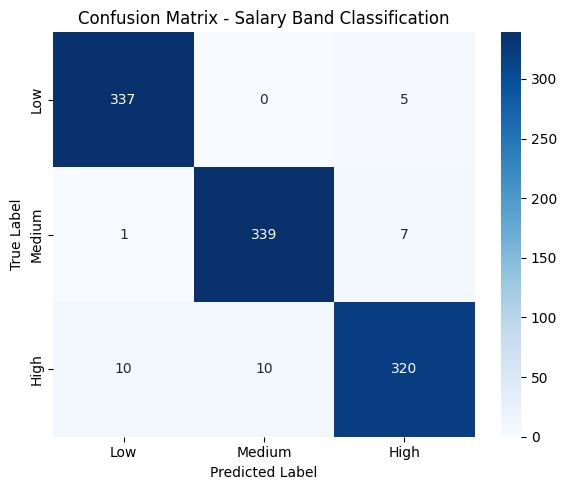

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Final selected model
final_classifier = best_hist

# Predictions on test data
y_pred = final_classifier.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Confusion Matrix - Salary Band Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Low", "Medium", "High"]
))

              precision    recall  f1-score   support

         Low       0.97      0.99      0.98       342
      Medium       0.97      0.98      0.97       347
        High       0.96      0.94      0.95       340

    accuracy                           0.97      1029
   macro avg       0.97      0.97      0.97      1029
weighted avg       0.97      0.97      0.97      1029



## Feature Importance (Validation Model)

This plot shows the importance of input features for the best Bagging model obtained using GridSearchCV.

Feature importance dictionary created for model metadata.
Computed Feature Importance:
{'Age': np.float64(0.10612244897959186), 'Gender': np.float64(0.014480077745383891), 'Education Level': np.float64(0.05481049562682218), 'Job Title': np.float64(0.23294460641399417), 'Years of Experience': np.float64(0.5490767735665696), 'Country': np.float64(0.0016520894071914705), 'Senior': np.float64(0.03022351797862003)}


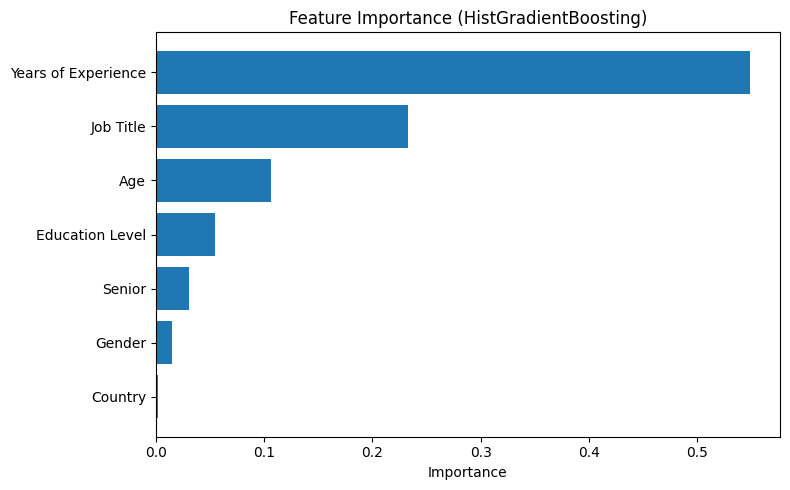

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# get best pipeline
best_pipeline = hist_grid.best_estimator_

# compute permutation importance
perm_importance = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# IMPORTANT: permutation importance corresponds to original features
feature_names = X_test.columns
importances = perm_importance.importances_mean

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# ---- Create dictionary for saving in metadata later ----
feature_importance_dict = dict(zip(feature_names, importances))

print("Feature importance dictionary created for model metadata.")
print("Computed Feature Importance:")
print(feature_importance_dict)
# ---- Plot for notebook visualization ----
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance (HistGradientBoosting)")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [41]:
from sklearn.inspection import permutation_importance

# Compute permutation importance on the trained pipeline
perm_importance_cls = permutation_importance(
    final_classifier,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Use original feature names
feature_names_cls = X_test.columns
importances_cls = perm_importance_cls.importances_mean

# Convert to dictionary for saving
feature_importance_dict = dict(zip(feature_names_cls, importances_cls))

print("Computed Feature Importance:")
print(feature_importance_dict)

Computed Feature Importance:
{'Age': np.float64(0.1215743440233236), 'Gender': np.float64(0.017978620019436297), 'Education Level': np.float64(0.05238095238095235), 'Job Title': np.float64(0.2428571428571428), 'Years of Experience': np.float64(0.5721088435374149), 'Country': np.float64(0.0070942662779397096), 'Senior': np.float64(0.03236151603498536)}


## Final Model Training on Full Dataset

After selecting the best-performing model (BaggingClassifier) and determining the optimal hyperparameters using GridSearchCV, the model is retrained using the entire dataset.

This ensures that the final deployed model benefits from all available training data.

In [48]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Extract best parameters from GridSearch
best_params = hist_grid.best_params_

# Build final pipeline
final_classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            learning_rate=best_params["classifier__learning_rate"],
            max_depth=best_params["classifier__max_depth"],
            max_iter=best_params["classifier__max_iter"],
            l2_regularization=best_params["classifier__l2_regularization"],
            random_state=42
        ))
    ]
)

# Train on FULL dataset
final_classifier.fit(X, y)

# ---- Compute metrics using earlier test set ----

y_test_pred = best_hist.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average="macro")
recall = recall_score(y_test, y_test_pred, average="macro")
f1 = f1_score(y_test, y_test_pred, average="macro")
cm = confusion_matrix(y_test, y_test_pred).tolist()

# ---- Package model + metadata ----

classifier_package = {
    "model": final_classifier,
    "metadata": {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "confusion_matrix": cm,
        "best_params": best_params,
        "model_type": "HistGradientBoostingClassifier",
        "problem_type": "Salary Band Classification",
        "feature_importance": feature_importance_dict,
    }
}

# Save
joblib.dump(classifier_package, "model/salary_band_classifier.pkl")

print("Classification model trained on full dataset and saved.")
print("Saved metrics:", classifier_package["metadata"])

Classification model trained on full dataset and saved.
Saved metrics: {'accuracy': 0.967930029154519, 'precision_macro': 0.9678643103851693, 'recall_macro': 0.967833944168024, 'f1_macro': 0.9677768258727779, 'confusion_matrix': [[337, 0, 5], [1, 339, 7], [10, 10, 320]], 'best_params': {'classifier__l2_regularization': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': None, 'classifier__max_iter': 100}, 'model_type': 'HistGradientBoostingClassifier', 'problem_type': 'Salary Band Classification', 'feature_importance': {'Age': np.float64(0.10612244897959186), 'Gender': np.float64(0.014480077745383891), 'Education Level': np.float64(0.05481049562682218), 'Job Title': np.float64(0.23294460641399417), 'Years of Experience': np.float64(0.5490767735665696), 'Country': np.float64(0.0016520894071914705), 'Senior': np.float64(0.03022351797862003)}}


In [49]:
import joblib

# Load saved package
package = joblib.load("model/salary_band_classifier.pkl")

# Extract model and metadata
loaded_model = package["model"]
metadata = package["metadata"]

print("Loaded model type:", type(loaded_model))
print("Classifier inside pipeline:", type(loaded_model.named_steps["classifier"]))

print("\nSaved Model Metadata:")
for key, value in metadata.items():
    print(f"{key}: {value}")

Loaded model type: <class 'sklearn.pipeline.Pipeline'>
Classifier inside pipeline: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>

Saved Model Metadata:
accuracy: 0.967930029154519
precision_macro: 0.9678643103851693
recall_macro: 0.967833944168024
f1_macro: 0.9677768258727779
confusion_matrix: [[337, 0, 5], [1, 339, 7], [10, 10, 320]]
best_params: {'classifier__l2_regularization': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': None, 'classifier__max_iter': 100}
model_type: HistGradientBoostingClassifier
problem_type: Salary Band Classification
feature_importance: {'Age': np.float64(0.10612244897959186), 'Gender': np.float64(0.014480077745383891), 'Education Level': np.float64(0.05481049562682218), 'Job Title': np.float64(0.23294460641399417), 'Years of Experience': np.float64(0.5490767735665696), 'Country': np.float64(0.0016520894071914705), 'Senior': np.float64(0.03022351797862003)}


## Feature Importance (Final Model Trained on Full Dataset)

This plot shows the importance of features for the final Bagging classifier trained on the entire dataset using the best hyperparameters obtained from GridSearchCV.

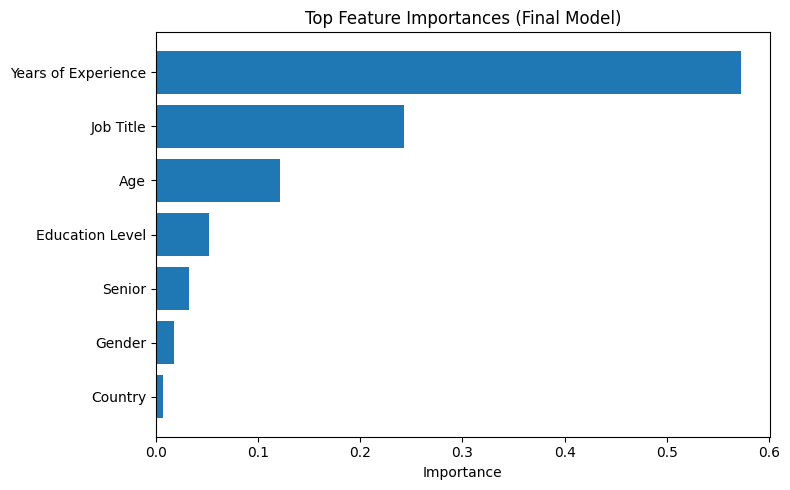

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Compute permutation importance on final trained pipeline
perm_importance_final = permutation_importance(
    final_classifier,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Use original dataset feature names
feature_names_final = X_test.columns
importances_final = perm_importance_final.importances_mean

importance_df_final = pd.DataFrame({
    "Feature": feature_names_final,
    "Importance": importances_final
}).sort_values("Importance", ascending=False)

# Plot
plt.figure(figsize=(8,5))

plt.barh(
    importance_df_final["Feature"][:10],
    importance_df_final["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top Feature Importances (Final Model)")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

## Model Sanity Test Suite

This section validates the deployed classification model using a curated set of
test cases covering:

- typical real-world inputs
- boundary cases
- extreme experience values
- different job roles
- different countries
- senior vs non-senior roles

This ensures the trained model behaves logically before integrating it into the Streamlit application.

In [37]:
import joblib
import pandas as pd

# -----------------------------
# Load saved model
# -----------------------------

package = joblib.load("model/salary_band_classifier.pkl")
model = package["model"]

print("Model loaded successfully")

# -----------------------------
# Test cases
# -----------------------------

test_cases = [

# NORMAL CASES
{"Age":32,"Gender":"Male","Education Level":1,"Job Title":"Software Engineer","Years of Experience":5,"Country":"UK","Senior":0},
{"Age":28,"Gender":"Female","Education Level":2,"Job Title":"Data Analyst","Years of Experience":3,"Country":"USA","Senior":0},
{"Age":45,"Gender":"Male","Education Level":3,"Job Title":"Manager","Years of Experience":15,"Country":"Canada","Senior":1},
{"Age":36,"Gender":"Female","Education Level":1,"Job Title":"Sales Associate","Years of Experience":7,"Country":"USA","Senior":0},
{"Age":52,"Gender":"Male","Education Level":2,"Job Title":"Director","Years of Experience":20,"Country":"USA","Senior":1},
{"Age":29,"Gender":"Male","Education Level":1,"Job Title":"Marketing Analyst","Years of Experience":2,"Country":"USA","Senior":0},
{"Age":42,"Gender":"Female","Education Level":2,"Job Title":"Product Manager","Years of Experience":12,"Country":"USA","Senior":1},
{"Age":31,"Gender":"Male","Education Level":1,"Job Title":"Sales Manager","Years of Experience":4,"Country":"China","Senior":0},

# EARLY CAREER
{"Age":22,"Gender":"Male","Education Level":1,"Job Title":"Junior Developer","Years of Experience":0.5,"Country":"USA","Senior":0},
{"Age":23,"Gender":"Female","Education Level":1,"Job Title":"Marketing Intern","Years of Experience":0.2,"Country":"UK","Senior":0},
{"Age":24,"Gender":"Male","Education Level":1,"Job Title":"Help Desk Analyst","Years of Experience":1,"Country":"Australia","Senior":0},

# MID CAREER
{"Age":35,"Gender":"Male","Education Level":2,"Job Title":"Data Scientist","Years of Experience":8,"Country":"USA","Senior":0},
{"Age":37,"Gender":"Female","Education Level":2,"Job Title":"UX Designer","Years of Experience":9,"Country":"Canada","Senior":0},
{"Age":40,"Gender":"Male","Education Level":2,"Job Title":"Project Manager","Years of Experience":12,"Country":"UK","Senior":1},

# SENIOR LEVEL
{"Age":48,"Gender":"Male","Education Level":3,"Job Title":"Chief Technology Officer","Years of Experience":20,"Country":"USA","Senior":1},
{"Age":50,"Gender":"Female","Education Level":3,"Job Title":"Director of Operations","Years of Experience":22,"Country":"Canada","Senior":1},
{"Age":47,"Gender":"Male","Education Level":3,"Job Title":"Research Director","Years of Experience":18,"Country":"UK","Senior":1},

# DIFFERENT COUNTRIES
{"Age":34,"Gender":"Male","Education Level":2,"Job Title":"Business Analyst","Years of Experience":6,"Country":"China","Senior":0},
{"Age":38,"Gender":"Female","Education Level":2,"Job Title":"Public Relations Manager","Years of Experience":10,"Country":"Australia","Senior":0},
{"Age":41,"Gender":"Female","Education Level":2,"Job Title":"Marketing Manager","Years of Experience":13,"Country":"USA","Senior":1},

# EDGE EXPERIENCE
{"Age":26,"Gender":"Male","Education Level":1,"Job Title":"Accountant","Years of Experience":0,"Country":"UK","Senior":0},
{"Age":60,"Gender":"Male","Education Level":2,"Job Title":"Consultant","Years of Experience":35,"Country":"USA","Senior":1},

# UNSEEN JOB TITLES (MODEL ROBUSTNESS)
{"Age":33,"Gender":"Female","Education Level":2,"Job Title":"AI Engineer","Years of Experience":7,"Country":"USA","Senior":0},
{"Age":30,"Gender":"Male","Education Level":1,"Job Title":"Blockchain Developer","Years of Experience":5,"Country":"Canada","Senior":0},

# UNUSUAL COMBINATIONS
{"Age":27,"Gender":"Female","Education Level":3,"Job Title":"Research Scientist","Years of Experience":2,"Country":"USA","Senior":0},
{"Age":29,"Gender":"Male","Education Level":3,"Job Title":"Data Scientist","Years of Experience":3,"Country":"China","Senior":0},

# HIGH EXPERIENCE NON-SENIOR
{"Age":44,"Gender":"Male","Education Level":2,"Job Title":"Software Engineer","Years of Experience":18,"Country":"USA","Senior":0},

# LOW AGE HIGH TITLE
{"Age":26,"Gender":"Male","Education Level":2,"Job Title":"Product Manager","Years of Experience":4,"Country":"USA","Senior":1},

# COUNTRY EDGE
{"Age":35,"Gender":"Female","Education Level":1,"Job Title":"Marketing Specialist","Years of Experience":8,"Country":"Germany","Senior":0},

# EXTREME EDGE
{"Age":21,"Gender":"Male","Education Level":0,"Job Title":"Intern","Years of Experience":0,"Country":"USA","Senior":0},
{"Age":65,"Gender":"Female","Education Level":3,"Job Title":"Senior Advisor","Years of Experience":40,"Country":"UK","Senior":1}

]

# -----------------------------
# Convert to DataFrame
# -----------------------------

test_df = pd.DataFrame(test_cases)

# -----------------------------
# Predict
# -----------------------------

predictions = model.predict(test_df)

test_df["Predicted Salary Band"] = predictions

# -----------------------------
# Show results
# -----------------------------

print("Sanity Test Results")
print(test_df)

Model loaded successfully
Sanity Test Results
    Age  Gender  Education Level                 Job Title  \
0    32    Male                1         Software Engineer   
1    28  Female                2              Data Analyst   
2    45    Male                3                   Manager   
3    36  Female                1           Sales Associate   
4    52    Male                2                  Director   
5    29    Male                1         Marketing Analyst   
6    42  Female                2           Product Manager   
7    31    Male                1             Sales Manager   
8    22    Male                1          Junior Developer   
9    23  Female                1          Marketing Intern   
10   24    Male                1         Help Desk Analyst   
11   35    Male                2            Data Scientist   
12   37  Female                2               UX Designer   
13   40    Male                2           Project Manager   
14   48    Male         